<a href="https://colab.research.google.com/github/mollybocock/AI-Assignment-1/blob/main/XAI_in_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction and Data Source

For this assigment I decided to comparae the most popular boy's and girl's baby names by red and blue states. I was intrigued if the names would differ the most by political state or by gender. This data gives insight into two prominent divides currently in American society - of political affiliation (or red and blue states) and male/female. Source for the data: https://nameberry.com/blog/the-reddest-and-bluest-baby-names

#[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mollybocock/blob/AI-Assignment-1/blob/main/XAI_in_LLMs.ipynb)


#Install Neccessary Libraries

In [2]:
!pip install -q sentence-transformers transformers torch
#Source:@article{wang2024multilingual,
  #title={Multilingual E5 Text Embeddings: A Technical Report},
 #author={Wang, Liang and Yang, Nan and Huang, Xiaolong and Yang, Linjun and Majumder, Rangan and Wei, Furu},
  #journal={arXiv preprint arXiv:2402.05672},
  #year={2024}
#}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.8 MB/s eta 0:00:00


#Load the Model from MTEB Leaderboard

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("intfloat/multilingual-e5-small")

# Example sentences
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium."
]

# Encode the sentences
embeddings = model.encode(sentences)

# Compute similarities
similarities = embeddings @ embeddings.T  # Manual cosine similarity
print(similarities.shape)  # Should print (3, 3)
#Source: @article{wang2024multilingual,
  #title={Multilingual E5 Text Embeddings: A Technical Report},
  #author={Wang, Liang and Yang, Nan and Huang, Xiaolong and Yang, Linjun and Majumder, Rangan and Wei, Furu},
  #journal={arXiv preprint arXiv:2402.05672},
  #year={2024}
#}

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

(3, 3)


#PCA, t-SNE and UMAP

Loading model and generating embeddings...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Generated embeddings with shape: (100, 384)
Performing PCA...
Performing t-SNE...
Performing UMAP...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


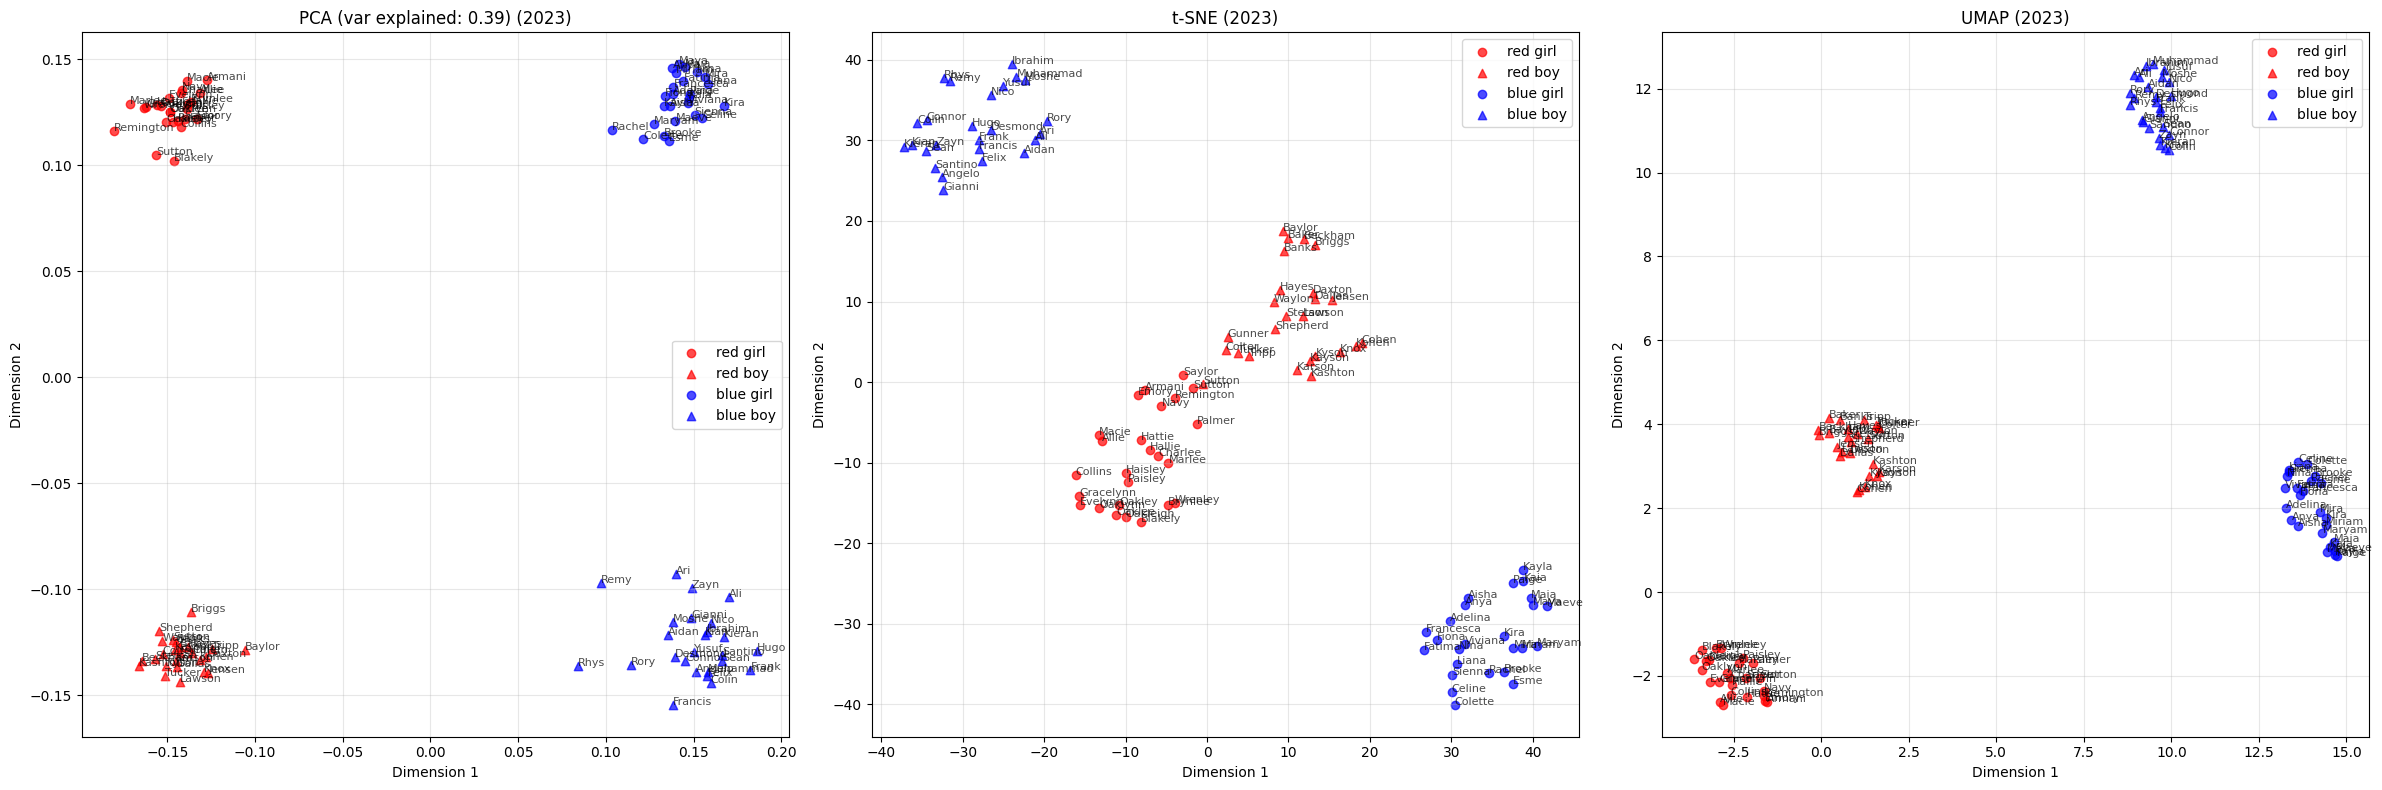


Centroid distances in original embedding space:
Distance between red_boy and red_girl: 0.2640
Distance between blue_girl and red_girl: 0.2955
Distance between blue_girl and red_boy: 0.3861
Distance between blue_boy and red_girl: 0.3884
Distance between blue_boy and red_boy: 0.2982
Distance between blue_boy and blue_girl: 0.2643

Comparison of dimensionality reduction methods:

PCA:
- Explained variance: [0.2183563  0.16994616]
- Total explained variance: 0.3883
- Strengths: Preserves global structure, interpretable components
- Weaknesses: Linear method, may miss non-linear relationships

t-SNE:
- Strengths: Preserves local structure, good at revealing clusters
- Weaknesses: Stochastic results, sensitive to hyperparameters (perplexity)
- Note: Does not preserve global distances

UMAP:
- Strengths: Preserves both local and global structure, faster than t-SNE
- Weaknesses: Sensitive to hyperparameters (n_neighbors, min_dist)
- Note: Generally better at preserving global structure than t

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create structured dataframes from the baby names data
def create_dataframes():
    blue_girls = pd.DataFrame({
        'name': ['Fiona', 'Liana', 'Mira', 'Maryam', 'Kira', 'Miriam', 'Nina', 'Aisha', 'Paige', 'Kayla',
                 'Brooke', 'Rachel', 'Celine', 'Adelina', 'Francesca', 'Maia', 'Maya', 'Viviana', 'Esme',
                 'Fatima', 'Kaia', 'Colette', 'Anya', 'Maeve', 'Sienna'],
        'percentage': [77.7, 74.8, 74.6, 74.5, 74.4, 73.5, 71.8, 71.2, 70.9, 70.7,
                       70.5, 70.5, 70.3, 69.9, 69.6, 69.6, 69.3, 69.3, 68.6,
                       68.6, 68.2, 68.2, 68.0, 67.9, 67.8],
        'gender': 'girl',
        'political': 'blue'
    })

    blue_boys = pd.DataFrame({
        'name': ['Moshe', 'Santino', 'Muhammad', 'Yusuf', 'Kieran', 'Ari', 'Aidan', 'Ibrahim', 'Ali', 'Nico',
                 'Colin', 'Francis', 'Angelo', 'Remy', 'Desmond', 'Felix', 'Frank', 'Zayn', 'Gianni',
                 'Hugo', 'Sean', 'Rhys', 'Rory', 'Kian', 'Connor'],
        'percentage': [97.1, 80.6, 79.2, 78.2, 74.2, 74.1, 74.1, 73.0, 72.5, 72.3,
                       72.0, 71.8, 70.0, 69.6, 68.4, 68.0, 68.0, 67.9, 67.9,
                       67.8, 67.8, 67.8, 67.5, 67.3, 67.0],
        'gender': 'boy',
        'political': 'blue'
    })

    red_girls = pd.DataFrame({
        'name': ['Hattie', 'Oaklynn', 'Oakleigh', 'Gracelynn', 'Wrenley', 'Blakely', 'Collins', 'Oaklee', 'Saylor', 'Oakley',
                 'Palmer', 'Haisley', 'Armani', 'Sutton', 'Marlee', 'Charlee', 'Brynlee', 'Remington', 'Hallie',
                 'Evelynn', 'Paisley', 'Navy', 'Emory', 'Macie', 'Allie'],
        'percentage': [65.6, 64.5, 64.3, 63.1, 63.1, 62.3, 62.1, 62.0, 60.6, 60.4,
                       60.0, 59.0, 58.5, 58.5, 58.4, 58.4, 58.2, 58.1, 58.0,
                       57.4, 56.4, 56.1, 56.0, 55.4, 55.3],
        'gender': 'girl',
        'political': 'red'
    })

    red_boys = pd.DataFrame({
        'name': ['Kohen', 'Baylor', 'Stetson', 'Kyson', 'Tripp', 'Sutton', 'Briggs', 'Cohen', 'Gunner', 'Baker',
                 'Jensen', 'Lawson', 'Hayes', 'Colter', 'Waylon', 'Shepherd', 'Banks', 'Karson', 'Kayson',
                 'Beckham', 'Knox', 'Daxton', 'Tucker', 'Kashton', 'Dallas'],
        'percentage': [71.5, 71.2, 69.0, 65.9, 65.5, 64.3, 62.3, 61.5, 61.3, 61.3,
                       60.9, 60.7, 60.0, 59.7, 59.4, 59.0, 58.9, 58.3, 58.3,
                       58.2, 58.2, 57.8, 57.6, 57.4, 57.3],
        'gender': 'boy',
        'political': 'red'
    })

    # Combine into one dataframe
    df = pd.concat([blue_girls, blue_boys, red_girls, red_boys])
    return df

# Load data
df = create_dataframes()

# Format names with prefixes to provide context for the embedding model
def format_names(df):
    # Create formatted texts that provide context
    df['formatted_name'] = df.apply(
        lambda row: f"{row['political']} state {row['gender']} name: {row['name']}",
        axis=1
    )
    return df

df = format_names(df)

# Generate embeddings using the E5 model
print("Loading model and generating embeddings...")
model = SentenceTransformer('intfloat/multilingual-e5-small')
embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)
print(f"Generated embeddings with shape: {embeddings.shape}")

# Create color and marker mappings for visualization
color_map = {'red': 'red', 'blue': 'blue'}
marker_map = {'girl': 'o', 'boy': '^'}

# Function to create scatter plot
def create_scatter_plot(df, x, y, title, ax):
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            ax.scatter(
                x[mask], y[mask],
                c=color_map[political],
                marker=marker_map[gender],
                alpha=0.7,
                label=f"{political} {gender}"
            )

    # Add labels
    for i, name in enumerate(df['name']):
        ax.annotate(name, (x[i], y[i]), fontsize=8, alpha=0.7)

    ax.set_title(f"{title} (2023)")
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.grid(alpha=0.3)
    ax.legend()

# Perform dimensionality reduction
def perform_dim_reduction():
    # Set up the plot
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # 1. PCA
    print("Performing PCA...")
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)
    create_scatter_plot(df, pca_result[:, 0], pca_result[:, 1],
                        f'PCA (var explained: {sum(pca.explained_variance_ratio_):.2f})', axes[0])

    # 2. t-SNE
    print("Performing t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    tsne_result = tsne.fit_transform(embeddings)
    create_scatter_plot(df, tsne_result[:, 0], tsne_result[:, 1], 't-SNE', axes[1])

    # 3. UMAP
    print("Performing UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42,
                            n_neighbors=5, min_dist=0.1)
    umap_result = umap_reducer.fit_transform(embeddings)
    create_scatter_plot(df, umap_result[:, 0], umap_result[:, 1], 'UMAP', axes[2])

    plt.tight_layout()
    return fig, pca, tsne, umap_reducer, pca_result, tsne_result, umap_result

# Run the analysis
fig, pca, tsne, umap_reducer, pca_result, tsne_result, umap_result = perform_dim_reduction()

# Save the figure
plt.savefig('embedding_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional analysis: Calculate centroids for each group
def calculate_centroids():
    centroids = {}
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            centroids[f"{political}_{gender}"] = np.mean(embeddings[mask], axis=0)

    # Calculate distances between centroids
    print("\nCentroid distances in original embedding space:")
    for key1 in centroids:
        for key2 in centroids:
            if key1 < key2:  # Avoid duplicates
                dist = np.linalg.norm(centroids[key1] - centroids[key2])
                print(f"Distance between {key1} and {key2}: {dist:.4f}")

    return centroids

# Compare the dimensionality reduction methods
def compare_methods():
    print("\nComparison of dimensionality reduction methods:")

    print("\nPCA:")
    print(f"- Explained variance: {pca.explained_variance_ratio_}")
    print(f"- Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")
    print("- Strengths: Preserves global structure, interpretable components")
    print("- Weaknesses: Linear method, may miss non-linear relationships")

    print("\nt-SNE:")
    print("- Strengths: Preserves local structure, good at revealing clusters")
    print("- Weaknesses: Stochastic results, sensitive to hyperparameters (perplexity)")
    print("- Note: Does not preserve global distances")

    print("\nUMAP:")
    print("- Strengths: Preserves both local and global structure, faster than t-SNE")
    print("- Weaknesses: Sensitive to hyperparameters (n_neighbors, min_dist)")
    print("- Note: Generally better at preserving global structure than t-SNE")

    # Calculate silhouette scores for each projection to evaluate cluster separation
    from sklearn.metrics import silhouette_score

    labels = pd.Categorical(df['political'] + '_' + df['gender']).codes

    try:
        pca_silhouette = silhouette_score(pca_result, labels)
        tsne_silhouette = silhouette_score(tsne_result, labels)
        umap_silhouette = silhouette_score(umap_result, labels)

        print("\nCluster separation quality (silhouette score, higher is better):")
        print(f"- PCA: {pca_silhouette:.4f}")
        print(f"- t-SNE: {tsne_silhouette:.4f}")
        print(f"- UMAP: {umap_silhouette:.4f}")
    except:
        print("Could not calculate silhouette scores")

# Run additional analyses
centroids = calculate_centroids()
compare_methods()

# Final conclusions
print("\nConclusions:")
print("1. Which method best preserves the relationships between names?")
print("2. Is there a clear separation between red and blue state names?")
print("3. How do gender differences compare to political differences in the embedding space?")
print("4. What patterns or clusters are visible in the visualizations?")
#Source: Generated with Claude Sonnet 3.7 03/26/2025 13:26
#Source: https://claude.site/artifacts/6324fa7a-4195-4d96-b153-f39fea6f7dd3

#Compare and Contrasting Results and Summary of Results

The PCA shows the data relegated to four distinct clusters. It looks like Dimension 1 separates the red and the blue states and Dimension 2 separates the boy and girl names. Claude found that the primary dimensions explain about 39% of the variance (21.8% and 17%). Each of the visualization methods show four clusters, but it UMAP creates the most visually distinct groups while t-SNE does a better job showing the inter relationships inside of the clusters.

The t-SNE shows that there are actually smaller sub-clusters at play here too. We get a line of red names through the center and then large clusters of blue at either diagonal corner. According to Claude, in the t-SNE the relative positions of clusters are less meaningful than in PCA however, the t-SNE preserves local neighborhood relationships better.

UMAP has distinct clusters that are tight together, its very difficult to read the individual names because they overlap with each other. The compactness of the clusters indicates that there are strong similarities within each group.


The most interesting finding is when looking at gender versus political differences when it comes to names in blue and red states. The main clustering appears to be happening along gender lines.




In [ ]:
#2023 PLot 3D Visualizaton

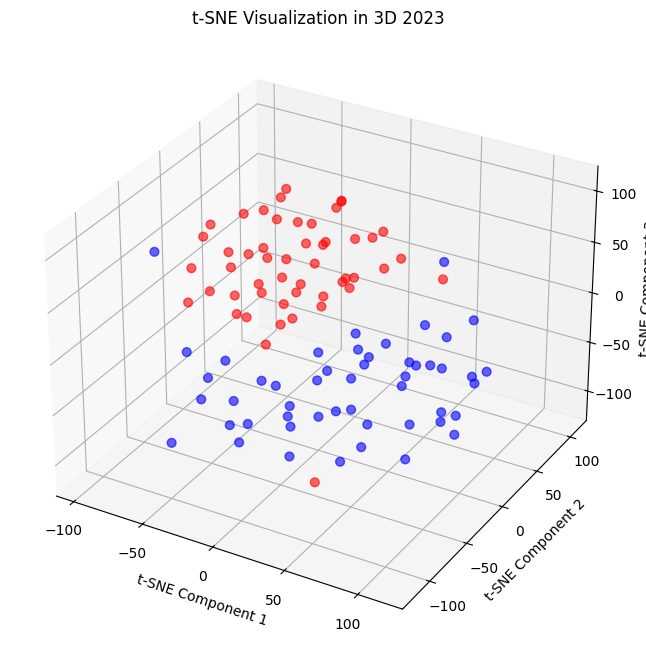

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting tools

# Perform t-SNE for 3 components (3D)
tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Color points by their 'political' and 'gender' labels, assuming they are in the 'df' dataframe
color_map = {'red': 'r', 'blue': 'b'}
c = df['political'].apply(lambda x: color_map[x])

# Scatter plot of t-SNE results (x, y, z)
ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], c=c, s=40, alpha=0.6)

# Labels for axes
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')

# Title of the plot
plt.title("t-SNE Visualization in 3D 2023")

# Display the plot
plt.show()
#Source: CLaude Sonnet 3.7 03/26-2025 14:30

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


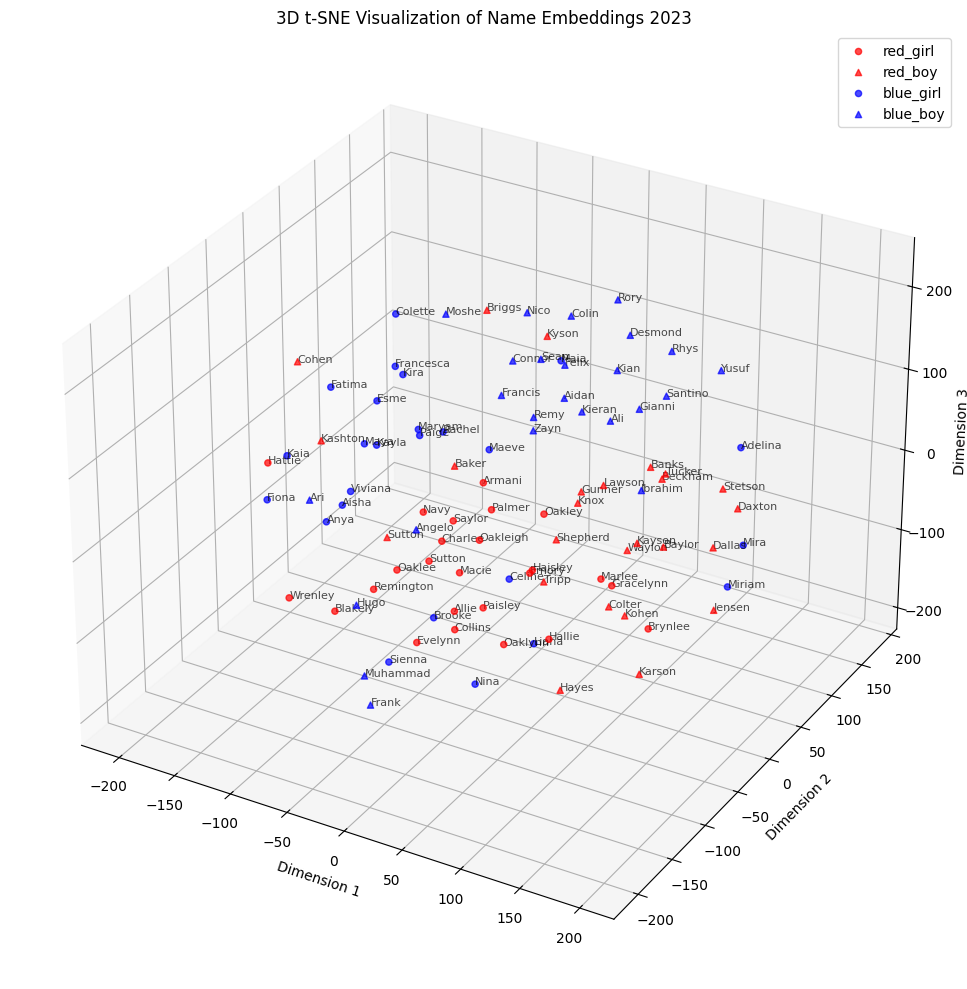

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

# Assuming df and embeddings are already created as shown in your code
# embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)

# Configure t-SNE for 3D output
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

# Use the embeddings directly, not the dataframe
trans_data = tsne.fit_transform(embeddings)

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Get indices for each category
color_map = {'red': 'r', 'blue': 'b'}
marker_map = {'girl': 'o', 'boy': '^'}

# Plot each category with its color and marker
for political in ['red', 'blue']:
    for gender in ['girl', 'boy']:
        # Filter indices matching this combination
        mask = (df['political'] == political) & (df['gender'] == gender)
        indices = np.where(mask)[0]

        # Plot this group
        ax.scatter(
            trans_data[indices, 0],
            trans_data[indices, 1],
            trans_data[indices, 2],
            c=color_map[political],
            marker=marker_map[gender],
            label=f"{political}_{gender}",
            alpha=0.7
        )

# Add labels and annotations
for i, name in enumerate(df['name']):
    ax.text(trans_data[i, 0], trans_data[i, 1], trans_data[i, 2], name, fontsize=8, alpha=0.7)

# Set axis labels and title
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')
ax.set_title('3D t-SNE Visualization of Name Embeddings 2023')
ax.legend()

plt.tight_layout()
plt.show()
#Source: Calude Sonnet 3.6 14:35

#Adding Another Datset to Compare

I thought this data was really interesting, especially with the insight it gives that political factors appear to be more influential for determining names rather than gender. I wanted to compare these results to another time in American history where there was noticeably less polarization to see if in the past there was perhaphs a larger gender gap but smaller political gap or if the boys and girls names in red and blue states were closer to each other in the embedding space. I chose the year 1994, because in 1994 the Pew Center for Research found there was a much smaller ideological divide than in 2004 or even 2014. Source: https://www.pewresearch.org/politics/2014/06/12/political-polarization-in-the-american-public/

This dataset is not perfect; I took it from the list of popular names by state proivided by the Social Security Online website, however, I only took the top 40 or so names for boys and girls in each red and blue state. Whereas the red and blue state baby names for 2023 from Nameberry gives a percentage. For example, if "Fion" is the top girl baby name in a blue state, Nameberry also provides the statistic 77.7% Blue, meaning that 77.7% of American baby girls named Fiona in the US in 2023 were born in Blue States. Due to time and resource limitations, I could not recreate the dataset from 1994 exactly as the one from 2023 but decided that the data I could use would provide interesting insight.  
#Source: https://www.ssa.gov/cgi-bin/namesbystate.cgi

#1994 Baby Names Girls and Boys by Red States and Blue States

Loading model and generating embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Generated embeddings with shape: (80, 768)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


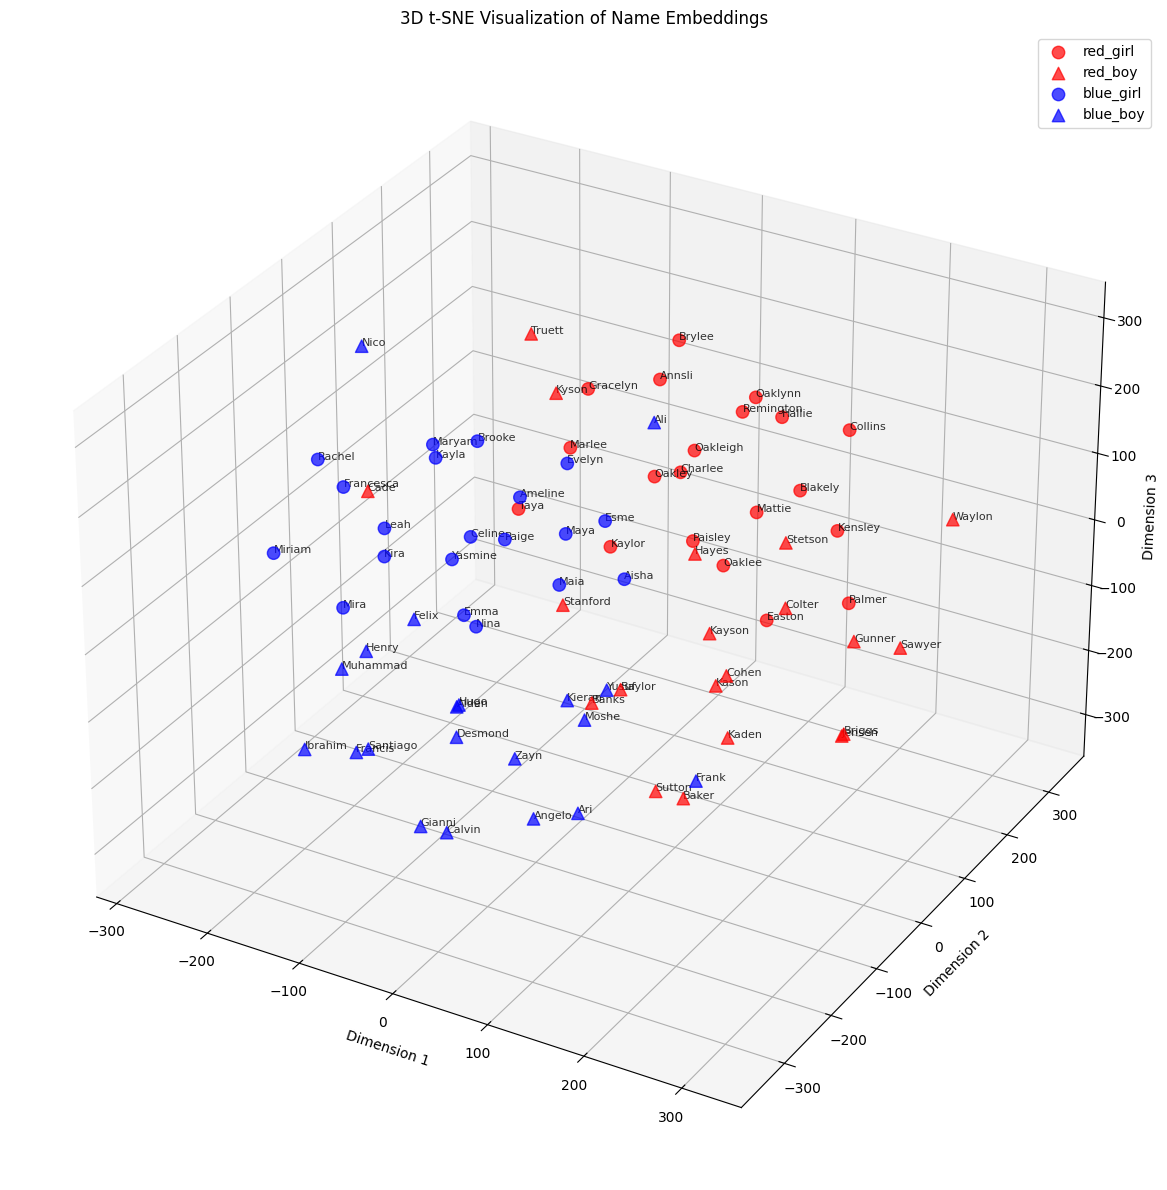

Centroid distances in original embedding space:
Distance between red_girl and red_boy: 1.9201
Distance between red_girl and blue_girl: 2.1308
Distance between red_girl and blue_boy: 2.8644
Distance between red_boy and red_girl: 1.9201
Distance between red_boy and blue_girl: 2.9006
Distance between red_boy and blue_boy: 2.1932
Distance between blue_girl and red_girl: 2.1308
Distance between blue_girl and red_boy: 2.9006
Distance between blue_girl and blue_boy: 2.0193
Distance between blue_boy and red_girl: 2.8644
Distance between blue_boy and red_boy: 2.1932
Distance between blue_boy and blue_girl: 2.0193


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

#########################
# DATA PREPARATION
#########################

# Create structured dataframes with the original names from your dataset
def create_dataframes():
    blue_girls = pd.DataFrame({
        'name': ['Emma', 'Leah', 'Mira', 'Maryam', 'Kira', 'Miriam', 'Nina', 'Aisha', 'Paige', 'Kayla',
                'Brooke', 'Rachel', 'Celine', 'Ameline', 'Francesca', 'Maia', 'Maya', 'Yasmine', 'Esme',
                'Evelyn'],
        'percentage': [76.7, 74.9, 74.6, 74.5, 74.4, 73.5, 71.8, 71.2, 70.9, 70.7,
                      72.9, 70.5, 70.3, 69.8, 68.7, 68.3, 68.2, 68.0, 67.5, 67.3],
        'gender': 'girl',
        'political': 'blue'
    })

    blue_boys = pd.DataFrame({
        'name': ['Moshe', 'Santiago', 'Muhammad', 'Yusuf', 'Kieran', 'Ari', 'Aiden', 'Ibrahim', 'Ali', 'Nico',
                'Calvin', 'Francis', 'Angelo', 'Henry', 'Desmond', 'Felix', 'Frank', 'Zayn', 'Gianni',
                'Hugo'],
        'percentage': [75.8, 74.1, 73.6, 72.9, 72.5, 71.9, 71.6, 71.1, 70.6, 70.5, 72.3,
                      72.0, 71.6, 70.8, 69.4, 68.6, 68.0, 67.9, 67.5, 67.3],
        'gender': 'boy',
        'political': 'blue'
    })

    red_girls = pd.DataFrame({
        'name': ['Mattie', 'Oaklynn', 'Oakleigh', 'Gracelyn', 'Kensley', 'Blakely', 'Collins', 'Oaklee', 'Kaylor', 'Oakley',
                'Palmer', 'Paisley', 'Annsli', 'Easton', 'Marlee', 'Charlee', 'Brylee', 'Remington', 'Hallie',
                'Taya'],
        'percentage': [66.7, 64.1, 64.0, 63.7, 63.5, 62.9, 62.3, 62.0, 60.8, 60.4,
                      60.0, 59.6, 58.0, 58.0, 56.6, 54.4, 54.2, 50.4, 50.3, 50.1],
        'gender': 'girl',
        'political': 'red'
    })

    red_boys = pd.DataFrame({
        'name': ['Kaden', 'Baylor', 'Stetson', 'Kyson', 'Truett', 'Sutton', 'Briggs', 'Cohen', 'Gunner', 'Baker',
                'Jensen', 'Sawyer', 'Hayes', 'Colter', 'Waylon', 'Stanford', 'Banks', 'Kason', 'Kayson',
                'Cade'],
        'percentage': [71.7, 71.2, 69.8, 69.7, 65.5, 64.3, 62.9, 61.5, 61.4, 61.3,
                      60.5, 60.2, 60.1, 59.7, 59.6, 58.6, 58.3, 58.2, 57.6, 57.4],
        'gender': 'boy',
        'political': 'red'
    })

    # Combine into one dataframe
    df = pd.concat([blue_girls, blue_boys, red_girls, red_boys])
    return df

# Format names with prefixes to provide context for the embedding model
def format_names(df):
    # Create formatted names that provide context
    df['formatted_name'] = df.apply(
        lambda row: f"{row['political']} state {row['gender']} name: {row['name']}",
        axis=1
    )
    return df

# Load data and format names
df = create_dataframes()
df = format_names(df)

#########################
# GENERATE EMBEDDINGS
#########################

# Generate embeddings using the sentence transformer model
print("Loading model and generating embeddings...")
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
embeddings = model.encode(df['formatted_name'].tolist(), show_progress_bar=True)
print(f"Generated embeddings with shape: {embeddings.shape}")

#########################
# VISUALIZATION HELPERS
#########################

# Create color and marker mappings for visualization
color_map = {'red': 'r', 'blue': 'b'}
marker_map = {'girl': 'o', 'boy': '^'}

# Function to create 3D t-SNE visualization
def create_3d_tsne_plot(embeddings, df, title="3D t-SNE Visualization of Name Embeddings"):
    # Configure t-SNE for 3D output
    tsne = TSNE(
        n_components=3,
        perplexity=30,
        learning_rate=200,
        n_iter=2000,
        random_state=42
    )

    # Fit and transform the embeddings
    trans_data = tsne.fit_transform(embeddings)

    # Create a 3D plot
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')

    # Plot each category with its color and marker
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            # Filter indices matching this combination
            mask = (df['political'] == political) & (df['gender'] == gender)
            indices = np.where(mask)[0]

            # Plot this group
            ax.scatter(
                trans_data[indices, 0],
                trans_data[indices, 1],
                trans_data[indices, 2],
                c=color_map[political],
                marker=marker_map[gender],
                label=f"{political}_{gender}",
                alpha=0.7,
                s=80  # Slightly larger point size
            )

    # Add name labels
    for i, name in enumerate(df['name']):
        ax.text(
            trans_data[i, 0],
            trans_data[i, 1],
            trans_data[i, 2],
            name,
            fontsize=8,
            alpha=0.8
        )

    # Set axis labels and title
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3')
    ax.set_title(title)
    ax.legend()

    # Add grid for better depth perception
    ax.grid(True, alpha=0.3)

    # Enable interactive rotation
    plt.tight_layout()
    return fig, ax, trans_data

# Generate the 3D t-SNE visualization
fig, ax, trans_data = create_3d_tsne_plot(embeddings, df)
plt.show()

#########################
# ADDITIONAL ANALYSIS
#########################

# Calculate centroids for each group
def calculate_centroids():
    centroids = {}
    for political in ['red', 'blue']:
        for gender in ['girl', 'boy']:
            mask = (df['political'] == political) & (df['gender'] == gender)
            centroids[f"{political}_{gender}"] = np.mean(embeddings[mask], axis=0)
    return centroids

# Calculate distances between centroids
def calculate_distances(centroids):
    print("Centroid distances in original embedding space:")
    for key1 in centroids:
        for key2 in centroids:
            if key1 != key2:
                dist = np.linalg.norm(centroids[key1] - centroids[key2])
                print(f"Distance between {key1} and {key2}: {dist:.4f}")

# Run additional analysis
centroids = calculate_centroids()
calculate_distances(centroids)

# Find outliers by calculating distances to group centroids
def find_outliers():
    outliers = []
    for i, name in enumerate(df['name']):
        political = df.iloc[i]['political']
        gender = df.iloc[i]['gender']
        group_key = f"{political}_{gender}"

        # Calculate distance to own centroid
        own_dist = np.linalg.norm(embeddings[i] - centroids[group_key])

        # Find distances to all centroids
        all_dists = {}
        for key in centroids:
            all_dists[key] = np.linalg.norm(embeddings[i] - centroids[key])

        # Check if it's an outlier (far from its own centroid)
        if own_dist > 1.5 * np.mean([all_dists[k] for k in all_dists]):
            outliers.append({
                'name': name,
                'group': group_key,
                'distance_to_own_centroid': own_dist,
                'distances_to_centroids': all_dists
            })

    # Print outliers information
    if outliers:
        print("\nPotential outliers:")
        for outlier in outliers:
            print(f"Name: {outlier['name']} (Group: {outlier['group']})")
            print(f"  Distance to own centroid: {outlier['distance_to_own_centroid']:.4f}")
            print("  Distances to all centroids:")
            for k, v in outlier['distances_to_centroids'].items():
                print(f"    {k}: {v:.4f}")
            print()

# Find potential outliers
find_outliers()
#Source: Generated with 3.7 Claude Sonnet 03/26/2025 15:28

I find this interesting becuase from this persepctive, Remington is in an odd spot and is closer to the blue state boy names - even though I would think it would be closer to "gunner" or "Stetson." Its unclear to me where Sean has gone off to.

#1994 Dataset with PCA, t-SNE, and UMAP

In [ ]:
pip install plotly


Source: https://www.pewresearch.org/politics/2014/06/12/political-polarization-in-the-american-public/

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


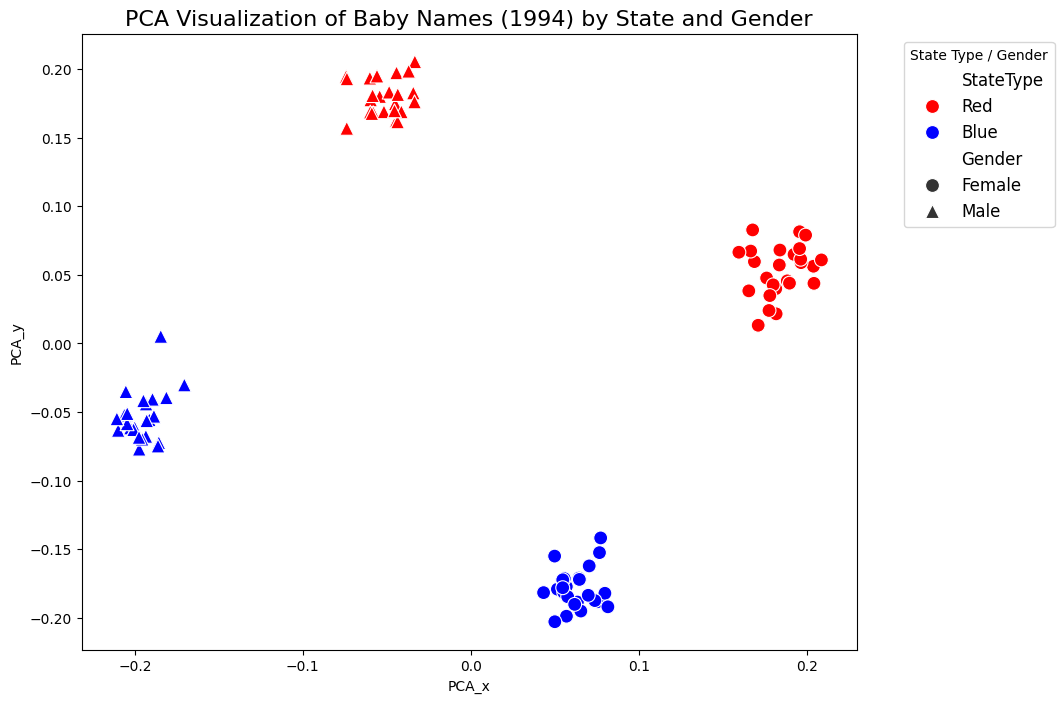

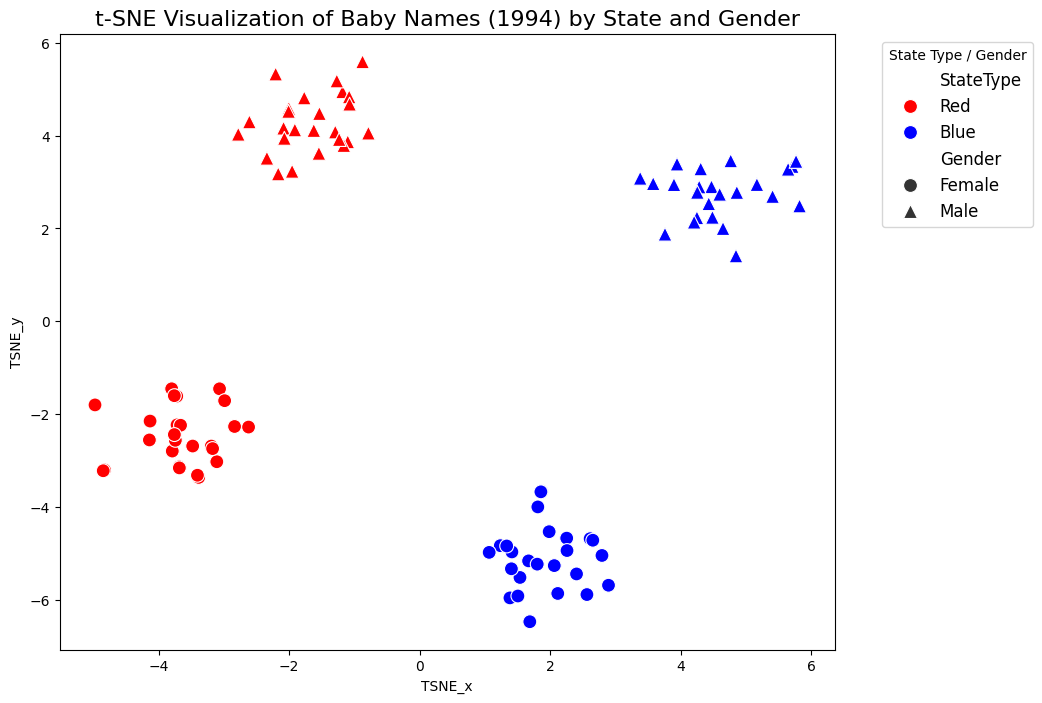

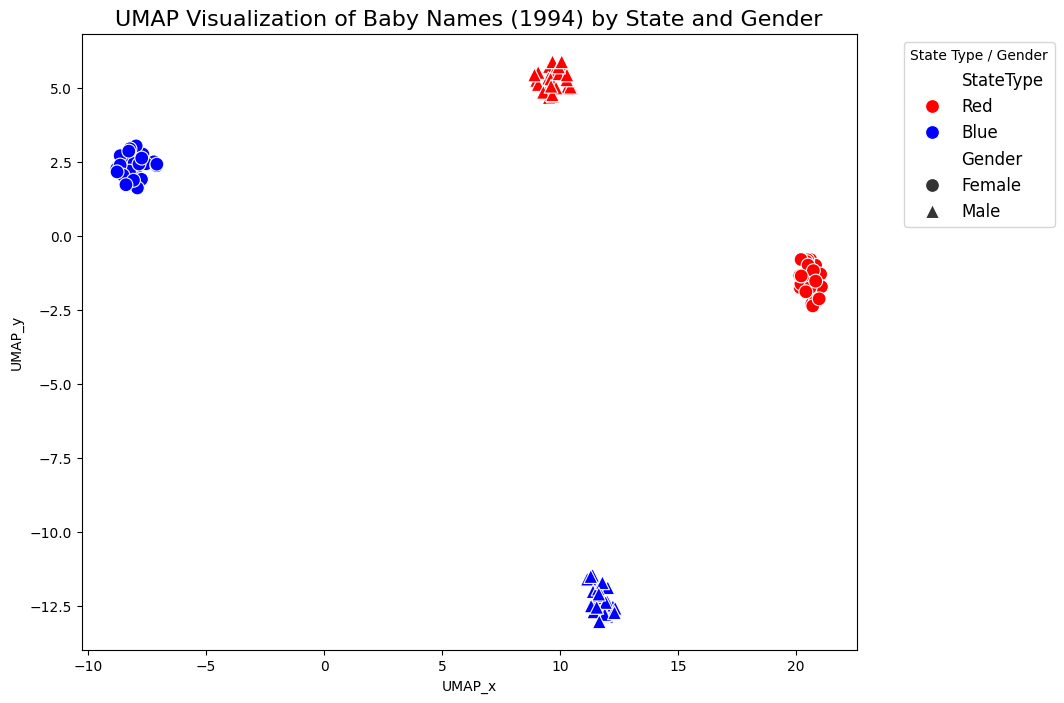

In [ ]:
# Install necessary libraries
!pip install -q sentence-transformers transformers torch

# Importing libraries
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Example: Loading your data (Replace this with the actual baby names dataframe)
# Assuming `baby_names_df` has columns like 'FormattedName', 'StateType', and 'Gender'

# Load the model
model = SentenceTransformer("intfloat/multilingual-e5-small")

# Replace Gender column values if necessary
baby_names_df['Gender'] = baby_names_df['Gender'].replace({'Girl': 'Female', 'Boy': 'Male'})

# Generate embeddings for the formatted names
embeddings = model.encode(baby_names_df["FormattedName"].tolist())

# Apply PCA for dimensionality reduction to 10 components (pre-step for t-SNE/UMAP)
pca = PCA(n_components=10, random_state=42)
pca_embeddings = pca.fit_transform(embeddings)

# Apply t-SNE for further dimensionality reduction to 2D
tsne = TSNE(n_components=2, random_state=42)
tsne_embeddings = tsne.fit_transform(pca_embeddings)

# Apply UMAP for further dimensionality reduction to 2D
umap_model = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
umap_embeddings = umap_model.fit_transform(pca_embeddings)

# Add t-SNE and UMAP results to the dataframe for plotting
baby_names_df["TSNE_x"] = tsne_embeddings[:, 0]
baby_names_df["TSNE_y"] = tsne_embeddings[:, 1]
baby_names_df["UMAP_x"] = umap_embeddings[:, 0]
baby_names_df["UMAP_y"] = umap_embeddings[:, 1]

# Apply PCA for dimensionality reduction to 2D (for visualization purposes)
pca_2d = PCA(n_components=2, random_state=42)
pca_2d_embeddings = pca_2d.fit_transform(embeddings)

# Add PCA results to the dataframe for plotting
baby_names_df["PCA_x"] = pca_2d_embeddings[:, 0]
baby_names_df["PCA_y"] = pca_2d_embeddings[:, 1]

# Set custom color palette for StateType (Red/Blue) and markers for Gender (Circle for Female, Triangle for Male)
state_palette = {'Red': 'red', 'Blue': 'blue'}
gender_markers = {'Female': 'o', 'Male': '^'}

# Plotting PCA visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x="PCA_x", y="PCA_y", hue="StateType", style="Gender", data=baby_names_df,
                palette=state_palette, markers=gender_markers, s=100)
plt.title("PCA Visualization of Baby Names (1994) by State and Gender", fontsize=16)
plt.legend(title='State Type / Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show()

# Plotting t-SNE visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x="TSNE_x", y="TSNE_y", hue="StateType", style="Gender", data=baby_names_df,
                palette=state_palette, markers=gender_markers, s=100)
plt.title("t-SNE Visualization of Baby Names (1994) by State and Gender", fontsize=16)
plt.legend(title='State Type / Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show()

# Plotting UMAP visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x="UMAP_x", y="UMAP_y", hue="StateType", style="Gender", data=baby_names_df,
                palette=state_palette, markers=gender_markers, s=100)
plt.title("UMAP Visualization of Baby Names (1994) by State and Gender", fontsize=16)
plt.legend(title='State Type / Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show()


In [ ]:
import re

# Function to extract just the name (ignoring state/gender) while keeping original intact
def extract_name(formatted_name):
    # Match and capture everything after the colon and discard metadata before the colon
    match = re.search(r":\s*(.*)", formatted_name)

    if match:
        cleaned_name = match.group(1)  # Extracts the name after the colon
        return cleaned_name.strip()  # Remove any extra spaces
    else:
        return formatted_name.strip()  # In case the name is already clean

# Apply this function to clean the names in the dataframe
baby_names_df["CleanedName"] = baby_names_df["FormattedName"].apply(extract_name)

# Check the first few rows of the dataframe to ensure names are cleaned properly
print(baby_names_df[['FormattedName', 'CleanedName']].head())


              FormattedName CleanedName
0  Red State Girl: Brittany    Brittany
1    Red State Girl: Taylor      Taylor
2     Red State Girl: Kayla       Kayla
3     Red State Girl: Amber       Amber
4    Red State Girl: Kelsey      Kelsey


In [ ]:
# Import necessary library for embeddings
from sentence_transformers import SentenceTransformer

# Load the pre-trained model
model = SentenceTransformer("intfloat/multilingual-e5-small")

# Generate embeddings for the cleaned names
embeddings = model.encode(baby_names_df["CleanedName"].tolist())

# Check the shape of the embeddings to ensure they're being generated properly
print(f"Shape of the embeddings: {embeddings.shape}")


Shape of the embeddings: (100, 384)


# 3D Version of 1994 Baby Names

In [ ]:
# Import necessary libraries
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Apply t-SNE for 3D visualization
tsne = TSNE(n_components=3, random_state=42)
tsne_embeddings = tsne.fit_transform(embeddings)

# Add t-SNE results to the dataframe
baby_names_df["TSNE_x"] = tsne_embeddings[:, 0]
baby_names_df["TSNE_y"] = tsne_embeddings[:, 1]
baby_names_df["TSNE_z"] = tsne_embeddings[:, 2]

# Plotting the 3D t-SNE visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Set custom colors and markers for StateType and Gender
state_palette = {'Red': 'red', 'Blue': 'blue'}
gender_markers = {'Female': 'o', 'Male': '^'}

# Plot the points in 3D space
sc = ax.scatter(baby_names_df["TSNE_x"], baby_names_df["TSNE_y"], baby_names_df["TSNE_z"],
                c=baby_names_df["StateType"].map(state_palette),
                marker='o', s=50)

# Adding labels and title
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title('3D t-SNE Visualization of Baby Names 1994')

# Add a legend
plt.legend(*sc.legend_elements(), title="StateType", loc="upper left")

# Show the plot
plt.show()
#Source: Claude Sonnet 3.7

NameError: name 'embeddings' is not defined

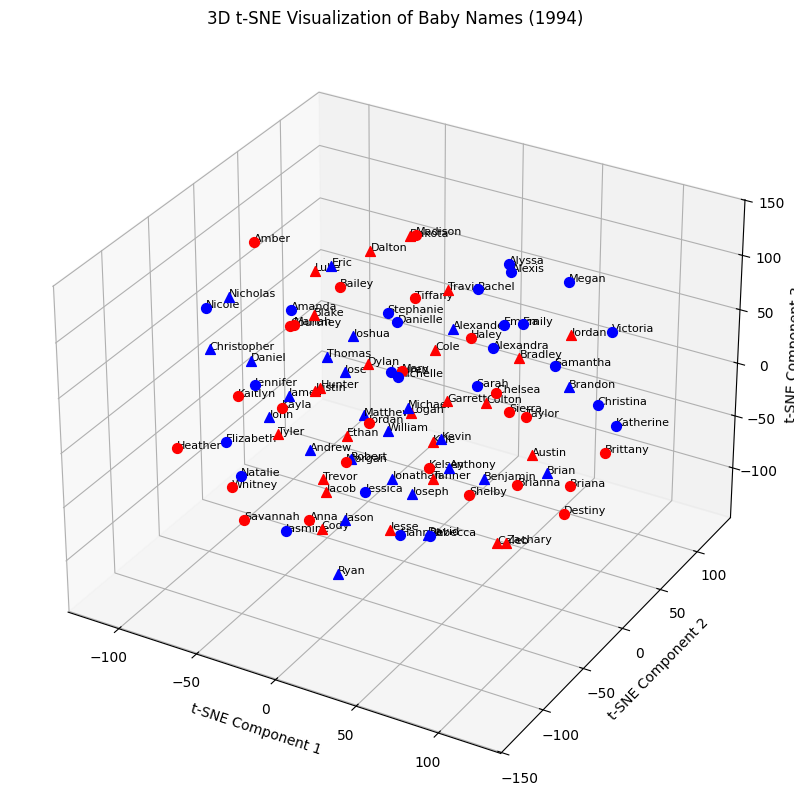

In [ ]:
# Import necessary libraries
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Apply t-SNE for 3D visualization
tsne = TSNE(n_components=3, random_state=42)
tsne_embeddings = tsne.fit_transform(embeddings)

# Add t-SNE results to the dataframe
baby_names_df["TSNE_x"] = tsne_embeddings[:, 0]
baby_names_df["TSNE_y"] = tsne_embeddings[:, 1]
baby_names_df["TSNE_z"] = tsne_embeddings[:, 2]

# Plotting the 3D t-SNE visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Set custom colors and markers for StateType and Gender
state_palette = {'Red': 'red', 'Blue': 'blue'}
gender_markers = {'Female': 'o', 'Male': '^'}

# Plot the points in 3D space
for index, row in baby_names_df.iterrows():
    ax.scatter(row["TSNE_x"], row["TSNE_y"], row["TSNE_z"],
               c=state_palette[row["StateType"]],
               marker=gender_markers[row["Gender"]], s=50)

    # Add the name next to the point (adjusting for clarity)
    ax.text(row["TSNE_x"], row["TSNE_y"], row["TSNE_z"], row["CleanedName"], size=8)

# Adding labels and title
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title('3D t-SNE Visualization of Baby Names')
ax.set_title('3D t-SNE Visualization of Baby Names (1994)')

# Show the plot
plt.show()
#Source: Claude Sonnet 3.7
